In [4]:
from pathlib import Path
import sys

import pandas as pd
root = Path.cwd().parent.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from weather_stylist.ml.synthetic_dataset import generate_synthetic_dataset
from weather_stylist.ml.train_model import main as train_warmth_model
from weather_stylist.ml.features import FEATURE_COLUMNS
from weather_stylist.ml.model_loader import get_regressor
from weather_stylist.adapters.user_bd.bd import engine as sync_engine, FeedbackORM, UserORM


ml_dir = root / "weather_stylist" / "ml"
data_dir = ml_dir / "data"
csv_path = data_dir / "synthetic_feedback.csv"
csv_path

PosixPath('/home/eiwa/final-project-adv-python/weather_stylist/ml/data/synthetic_feedback.csv')

## Модель комфортного индекса теплоты 

### Синтетический датасет

Сгенерируем синтетический датасет. В synthetic_dataset.generate_synthetic_dataset по умолчанию 5000 примеров


In [5]:
generate_synthetic_dataset(n_samples=5000)

synthetic dataset saved to /home/eiwa/final-project-adv-python/weather_stylist/ml/data/synthetic_feedback.csv


Пример синтетических данных

In [6]:
df = pd.read_csv(csv_path)  # первые 5 строк
df.head()


,temp_min,temp_max,wind_max,will_rain,thermo_profile,warmth_shift,required_warmth
0,7,16,12.589578,0,-1,0.0,5.0
1,15,20,0.785172,1,1,0.0,1.0
2,-1,-1,8.567557,1,1,0.0,8.0
3,-14,-10,1.172638,0,-1,0.0,14.0
4,-1,4,9.335293,1,1,0.0,5.0


Средняя информация по всем объектам:

In [7]:
df.describe(include="all")

,temp_min,temp_max,wind_max,will_rain,thermo_profile,warmth_shift,required_warmth
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.000000
mean,2.768600,7.756800,7.463790,0.502600,0.003600,0.0,7.456600
std,16.383624,16.061795,4.313386,0.500043,0.814444,0.0,5.800349
min,-30.000000,-20.000000,0.002434,0.000000,-1.000000,0.0,0.000000
25%,-11.000000,-6.000000,3.775856,0.000000,-1.000000,0.0,3.000000
50%,3.000000,8.000000,7.356483,1.000000,0.000000,0.0,6.000000
75%,17.000000,22.000000,11.209279,1.000000,1.000000,0.0,13.000000
max,35.000000,35.000000,14.991202,1.000000,1.000000,0.0,21.000000


### Обучение модели

Запускаем обучвение модели. Вызываем train_madel.py, который читает датасет, там происходит деление на train/test, считаются метрики, модель сохраняется

In [8]:
train_warmth_model()

MAE: 0.18772700426493777
R^2: 0.9978924771495371
model saved to /home/eiwa/final-project-adv-python/weather_stylist/ml/comfort_regressor.pkl


В качестве модели используется RandomForestRegressor из библиотеки scikit-learn с 200 деревьями (n_estimators=200) и ограничением глубины деревьев (max_depth=8), что позволяет моделировать нелинейную зависимость между погодой, профилем пользователя и требуемой «теплотой» комплекта, но при этом ограничивать переобучение.

In [9]:
reg = get_regressor()
reg

,n_estimators,200
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
sample = df.iloc[0]

X_sample = sample[FEATURE_COLUMNS].values.reshape(1, -1)
y_true = sample["required_warmth"]
y_pred = reg.predict(X_sample)[0]

print("y_true:", y_true)
print("y_pred:", y_pred)


y_true: 5.0
y_pred: 4.877398991710958


/home/eiwa/final-project-adv-python/hse_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


MAE on test: 0.188
R^2 on test: 0.998


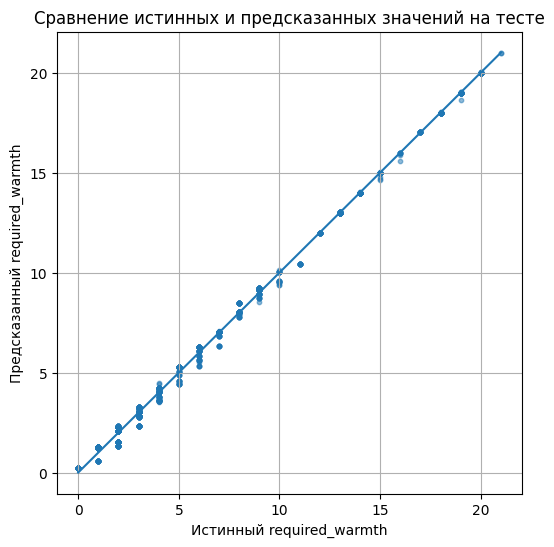

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

X = df[FEATURE_COLUMNS]
y = df["required_warmth"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred = reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE on test: {mae:.3f}")
print(f"R^2 on test: {r2:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=10)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Истинный required_warmth")
plt.ylabel("Предсказанный required_warmth")
plt.title("Сравнение истинных и предсказанных значений на тесте")
plt.grid(True)
plt.show()


### Покажем на примере свзяь с ботом

Соберём искусственный прогноз погоды на день

In [12]:
from weather_stylist.models.weather import DayForecast
from weather_stylist.models.user import User
from weather_stylist.ml.features import make_features

# пример прогноза на день
fake_forecast = DayForecast(
    city="Prague",
    min_temp=3.0,
    max_temp=9.0,
    wind_max=5.0,
    will_rain=True, 
    hourly=[]
)

# пример пользователя
fake_user = User(
    tg_id=123456,
    city="Prague",
    name="Test User",
    region="unknown",
    thermo_profile=0,  
    warmth_shift=0.0,
    feedback_count=0,
    cold_count=0,
    hot_count=0,
)

features_vec = make_features(fake_forecast, fake_user)
features_vec


[3.0, 9.0, 5.0, 1.0, 0.0, 0.0]

In [13]:
X = pd.DataFrame([features_vec], columns=FEATURE_COLUMNS)
reg.predict(X)[0]

np.float64(6.270972628093914)

По (forecast, user) с помощью `make_features` можно построить вектор признаков, тот же вектор корректно принимает регрессор из `comfort_regressor.pkl`

# Переход к реальным фидбекам

В начале проекта у нас не было пользовательских фидбеков, поэтому мы задали экспертные правила required_warmth_rule_based (температура + ветер + дождь + термопрофиль),
сгенерировали синтетический датасет synthetic_feedback.csv через synthetic_dataset.py,
обучили базовую модель comfort_regressor.pkl, которая аппроксимирует эти правила.
Благодаря этому бот адекватно работает даже при нулевых фидбеках.

После тестов и накопления 100+ записей в таблице feedback мы перещли ко второй стадии обучения.
Теперь мы не пытаемся заново предсказать весь target, а учим модель предсказывать небольшую поправку delta к базовому правилу.

- label = -1 (было холодно) $\Rightarrow$ delta = +K 
- label = 0 (ok) $\Rightarrow$ delta = 0 
- label = +1 (hot) $\Rightarrow$ delta = -K 

Синтетика при этом остаётся: для регресс-тестов, а сам бот опирается на новую тактику.

In [14]:
from pathlib import Path
import weather_stylist.adapters.user_bd.bd as bd

print("SYNC_DB_URL:", bd.SYNC_DB_URL)
print("DEFAULT_DB_PATH:", bd.DEFAULT_DB_PATH)

p = Path(bd.DEFAULT_DB_PATH)
print("exists:", p.exists(), "size:", p.stat().st_size, "bytes", "mtime:", p.stat().st_mtime)



SYNC_DB_URL: sqlite:////home/eiwa/final-project-adv-python/weather_stylist/adapters/user_bd/weather_stylist.db
DEFAULT_DB_PATH: /home/eiwa/final-project-adv-python/weather_stylist/adapters/user_bd/weather_stylist.db
exists: True size: 20480 bytes mtime: 1766589667.5445867


In [15]:
# Обучение delta-модели на реальных фидбеках из бд

import pandas as pd
from sqlalchemy import select

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
import joblib



# читаем реальные фидбеки 
stmt = (
    select(
        FeedbackORM.temp_min,
        FeedbackORM.temp_max,
        FeedbackORM.wind_max,
        FeedbackORM.will_rain,
        FeedbackORM.thermo_profile,
        UserORM.warmth_shift,
        FeedbackORM.label,
    )
    .join(UserORM, UserORM.tg_id == FeedbackORM.user_tg_id)
)

df_real = pd.read_sql(stmt, sync_engine)
print("real feedback rows:", len(df_real))
df_real.head()

real feedback rows: 152


,temp_min,temp_max,wind_max,will_rain,thermo_profile,warmth_shift,label
0,0.0,0.0,0.0,False,-1,0.000000,0
1,0.0,0.0,0.0,False,-1,0.000000,0
2,0.0,0.0,0.0,False,1,2.038903,-1
3,0.0,0.0,0.0,False,1,2.038903,0
4,0.0,0.0,0.0,False,1,-1.732048,-1


In [16]:
#  строим таргет delta и обучаем модель
df_real["will_rain"] = df_real["will_rain"].astype(int)
K = 1.0
df_real["delta"] = (-df_real["label"].clip(-1, 1)) * K

X = df_real[FEATURE_COLUMNS]
y = df_real["delta"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Простая стабильная модель для малых данных
delta_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])

delta_model.fit(X_train, y_train)

pred = delta_model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, pred))
print("R^2:", r2_score(y_test, pred))

MAE: 0.6523451272499656
R^2: -0.19324667831270292


In [17]:
# сохраняем delta-модель

from pathlib import Path

ml_dir = root / "weather_stylist" / "ml"
out_path = ml_dir / "comfort_delta_regressor.pkl"

joblib.dump(delta_model, out_path)
out_path


PosixPath('/home/eiwa/final-project-adv-python/weather_stylist/ml/comfort_delta_regressor.pkl')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, pred, s=15, alpha=0.7)

min_val = min(np.min(y_test), np.min(pred))
max_val = max(np.max(y_test), np.max(pred))
ax.plot([min_val, max_val], [min_val, max_val], linewidth=2)

ax.set_xlabel("Истинная delta")
ax.set_ylabel("Предсказанная delta")
ax.set_title("Delta-модель: сравнение истинных и предсказанных значений")
ax.grid(True)
plt.show()